<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº5
#### Manuel Helas
En este trabajo de hara un analizis de señales de las cuales se tiene una sola realizacion a llas cuales se les aplicara el metodo de estimacion de Welch para obtener su densidad espectral de potencia.
Dicho metodo funciona ventaneando el peridiograma de la señal para luego dividirla en diferentes segmentos incluido segmentos con solapamientos de segmenteos anteriores (se trabajara con solapamiento del 50%) y luego promediarlos para asi poder reducir la varianza.

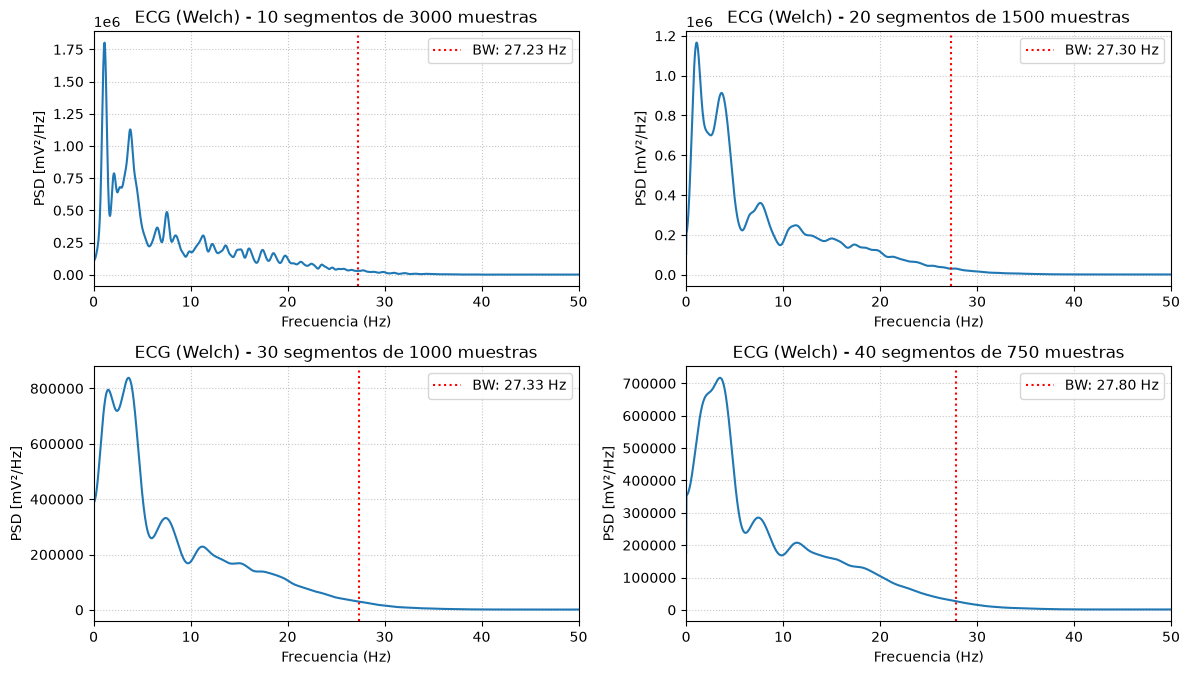

In [25]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt


def estimar_ancho_banda(frecuencias, espectro_psd, umbral):
    potencia_total = np.sum(espectro_psd)
    potencia_norm = np.cumsum(espectro_psd) / potencia_total
    
    indice_corte = np.searchsorted(potencia_norm, umbral)
    
    return frecuencias[indice_corte]

p = 0.98

fs_ecg = 1000 
ecg_one_lead = np.load('ecg_sin_ruido.npy')
lenecg = len(ecg_one_lead)


segmentos = [10, 20, 30, 40]

plt.figure(figsize=(12, 7))

bw_ecg_fin = 0 


for i, num_seg in enumerate(segmentos):
    plt.subplot(2, 2, i + 1)
    
    nperseg = int(lenecg / num_seg)
    frec_ecg, psd_ecg = sig.welch(ecg_one_lead, fs=fs_ecg, nperseg=nperseg, noverlap=nperseg//2, detrend='linear', nfft=lenecg)
    
    plt.plot(frec_ecg, psd_ecg)
    plt.xlim(0, 50)
    
    BW_ECG = ancho_banda(frec_ecg, psd_ecg, p)
    
    
    if num_seg == 10: 
        bw_ecg_fin = BW_ECG
       
   
    plt.axvline(BW_ECG, label=f'BW: {BW_ECG:.2f} Hz', color='red', linestyle=':', linewidth=1.5)
    plt.title(f"ECG (Welch) - {num_seg} segmentos de {nperseg} muestras")
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("PSD [mV²/Hz]")
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
plt.tight_layout()
plt.show()



Analizando los 4 graficos, se puede ver perfectamente el funcionamiento del estimador de welch, que tomando pocos segmentos pero con muchas muestras en cada uno, el PSD tiene mas resolucion espectral lo que nos permite ver una diferenciacion entre la frecuencia fundamental y sus armonicos pero a costo de tener una varianza mayor a diferencia de cuando tenemos mas segmentos para promediar pero cada uno con menor cantidad de muestras, que se ve una curva mucho mas suave pero con una mucha menor resolucion espectral que hace que el pico de la frecuencia fundamental se junte con la de los armonicos debido a que al haber menos N, el lobulo principal de la ventana usada es ams grande y agarra mas picos logrando que sean indistinguibles entre si. Por otro lado el ancho de banda de la señal no varia sino que se mantiene por lo cual se puede asumir que el estimador usado es robusto.

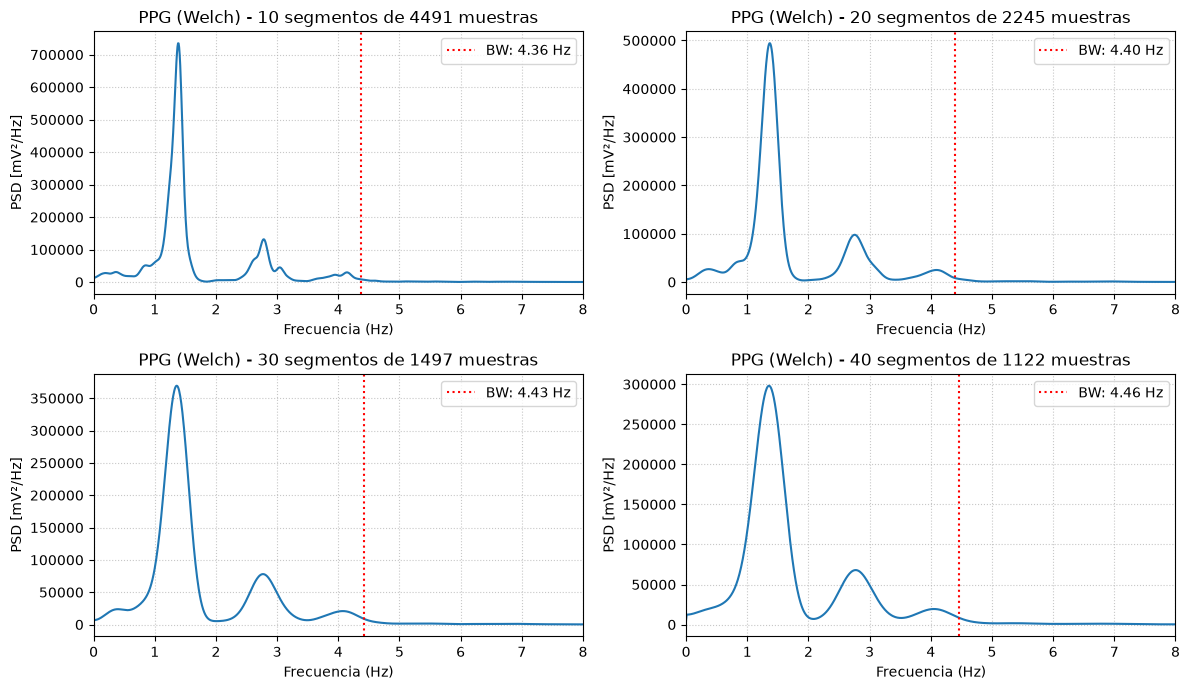

In [14]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt

# Tu función modificada
def estimar_ancho_banda(frecuencias, espectro_psd, umbral):
    potencia_total = np.sum(espectro_psd)
    potencia_norm = np.cumsum(espectro_psd) / potencia_total
    
    indice_corte = np.searchsorted(potencia_norm, umbral)
    
    return frecuencias[indice_corte]

p = 0.98

# Cambios para PPG: fs = 400 Hz y archivo ppg_sin_ruido.npy
fs_ppg = 400 
ppg_signal = np.load('ppg_sin_ruido.npy')
lenppg = len(ppg_signal)

segmentos = [10, 20, 30, 40]

plt.figure(figsize=(12, 7))

bw_ppg_fin = 0 

for i, num_seg in enumerate(segmentos):
    plt.subplot(2, 2, i + 1)
    
    nperseg = int(lenppg / num_seg)
    frec_ppg, psd_ppg = sig.welch(ppg_signal, fs=fs_ppg, nperseg=nperseg, noverlap=nperseg//2, detrend='linear', nfft=lenppg)
    
    plt.plot(frec_ppg, psd_ppg)
    
   
    plt.xlim(0, 8) 
    
   
    BW_PPG = estimar_ancho_banda(frec_ppg, psd_ppg, p)
    
  
    if num_seg == 20: 
        bw_ppg_fin = BW_PPG
       
    plt.axvline(BW_PPG, label=f'BW: {BW_PPG:.2f} Hz', color='red', linestyle=':', linewidth=1.5)
    plt.title(f"PPG (Welch) - {num_seg} segmentos de {nperseg} muestras")
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("PSD [mV²/Hz]")
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()

plt.tight_layout()
plt.show()



Al tener un ancho de banda mucho menor que el del ECG, para la PPG se pueden usar muchas menos muestras debido a la menor frecuencia de muestreo (que marca el ancho de banda digital) y, aún así, mantener una buena resolución espectral.

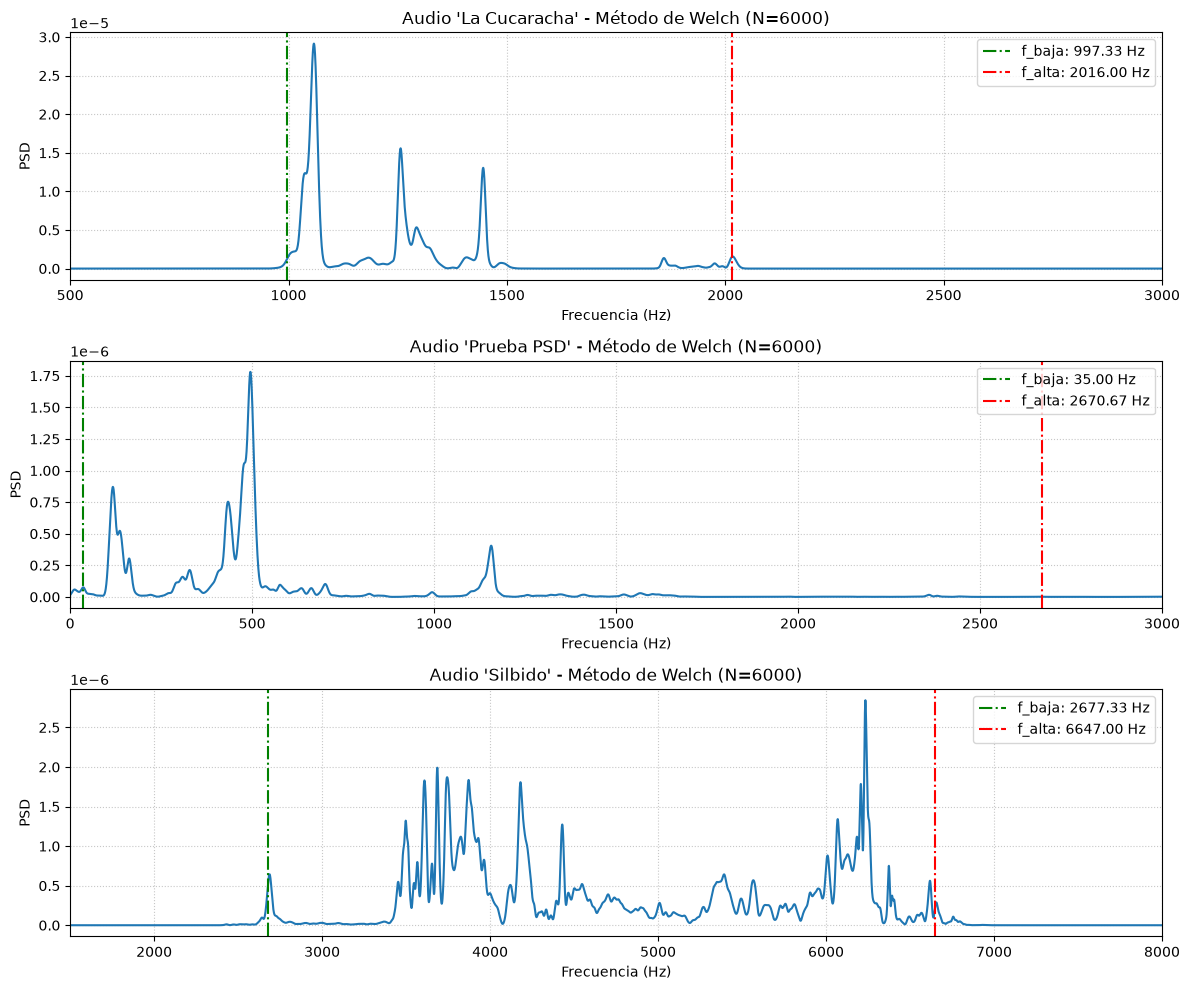

In [23]:
import numpy as np
from scipy import signal as sig
import scipy.io as sio
import matplotlib.pyplot as plt


def estimar_ancho_banda_audio(frecuencias, espectro_psd, umbral):
    potencia_total = np.sum(espectro_psd)
    potencia_norm = np.cumsum(espectro_psd) / potencia_total
    
    limite_inferior = (1 - umbral) / 2
    limite_superior = 1 - limite_inferior
    
    idx_baja = np.searchsorted(potencia_norm, limite_inferior)
    idx_alta = np.searchsorted(potencia_norm, limite_superior)
    
    f_baja = frecuencias[idx_baja]
    f_alta = frecuencias[idx_alta]
    ancho_banda = f_alta - f_baja
    
    return f_baja, f_alta, ancho_banda

p = 0.98


lista_audios = [
    ('la cucaracha.wav', 'La Cucaracha', [500, 3000]),
    ('prueba psd.wav', 'Prueba PSD', [0, 3000]),
    ('silbido.wav', 'Silbido', [1500, 8000])
]


plt.figure(figsize=(12, 10))
datos_audios = []
for i, (archivo, titulo, x_lims) in enumerate(lista_audios):
    fs_audio, wav_data = sio.wavfile.read(archivo)
    lenwav = len(wav_data)
    datos_audios.append((titulo, f_baja, f_alta, BW_audio))
    
    num_seg = 24
    nperseg = int(lenwav / num_seg)
    
    frec_audio, psd_audio = sig.welch(wav_data, fs=fs_audio, nperseg=nperseg, noverlap=nperseg//2, detrend='linear', nfft=lenwav)
    
    f_baja, f_alta, BW_audio = estimar_ancho_banda_audio(frec_audio, psd_audio, p)
    
    plt.subplot(3, 1, i + 1)
    plt.plot(frec_audio, psd_audio)
    
    plt.axvline(f_baja, label=f'f_baja: {f_baja:.2f} Hz', color='green', linestyle='-.', linewidth=1.5)
    plt.axvline(f_alta, label=f'f_alta: {f_alta:.2f} Hz', color='red', linestyle='-.', linewidth=1.5)
    
    plt.title(f"Audio '{titulo}' - Método de Welch (N={nperseg})")
    plt.xlim(x_lims)
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("PSD")
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Se ve a simple vista cómo, a diferencia de las señales anteriores, las de audio se comportan como pasabanda y tienen una frecuencia de muestreo y ancho de banda bastante más grandes. Por lo cual, el método de Welch sí o sí requiere mayor resolución espectral y un $N$ bien grande en cada segmento para que se puedan distinguir bien los tonos, a costo de una varianza superior.

In [26]:
print("RESULTADOS: ESTIMACIÓN DE ANCHO DE BANDA")
print("-" * 68)
print(f'{"Tipo de Señal":<16} | {"F_baja [Hz]":>13} | {"F_alta [Hz]":>13} | {"BW [Hz]":>13}')
print("-" * 68)
print(f'{"ECG":<16} | {0.0:>13.2f} | {bw_ecg_fin:>13.2f} | {bw_ecg_fin:>13.2f}')
print(f'{"PPG":<16} | {0.0:>13.2f} | {bw_ppg_fin:>13.2f} | {bw_ppg_fin:>13.2f}')

# Imprimimos extrayendo los datos de la lista cruzada (el índice 1 es f_baja, 2 es f_alta, 3 es bw)
print(f'{"Canción":<16} | {datos_audios[1][1]:>13.2f} | {datos_audios[1][2]:>13.2f} | {datos_audios[1][3]:>13.2f}')
print(f'{"Frase hablada":<16} | {datos_audios[2][1]:>13.2f} | {datos_audios[2][2]:>13.2f} | {datos_audios[2][3]:>13.2f}')
print(f'{"Silbido":<16} | {datos_audios[0][1]:>13.2f} | {datos_audios[0][2]:>13.2f} | {datos_audios[0][3]:>13.2f}')
print("-" * 68)

RESULTADOS: ESTIMACIÓN DE ANCHO DE BANDA
--------------------------------------------------------------------
Tipo de Señal    |   F_baja [Hz] |   F_alta [Hz] |       BW [Hz]
--------------------------------------------------------------------
ECG              |          0.00 |         27.23 |         27.23
PPG              |          0.00 |          4.40 |          4.40
Canción          |        997.33 |       2016.00 |       1018.67
Frase hablada    |         35.00 |       2670.67 |       2635.67
Silbido          |       2677.33 |       6647.00 |       3969.67
--------------------------------------------------------------------


Viendo la tabla de valores, se refleja lo mencionado previamente, cómo a diferencia de los audios las señales biomédicas se manejan en las frecuencias bajas y con una necesidad de una frecuencia de muestreo mucho menor. Lo que nos marca qué cantidad tanto de segmentos como de muestras por segmento nos va a convenir tomar (cuanto menor el ancho de banda que ocupe nos podemos permitir tomar menor N y así mejorar la suavidad de la curva de la señal reduciendo su varianza).